Loading unified velocity data...
Full Field: 29161 points | Sensor: 363 points
Computing Full-Field POD...
Computing Sensor Strip POD...
Computing Cross-Correlation Matrix...


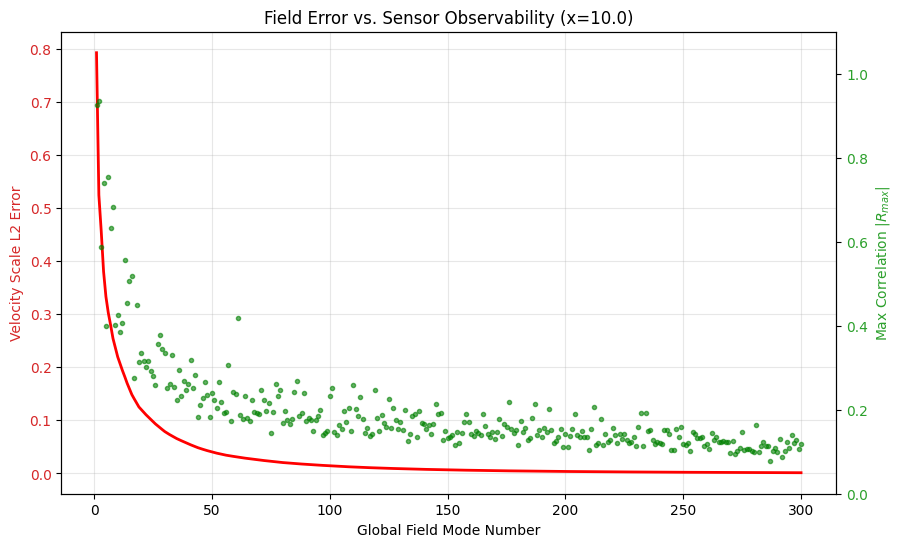

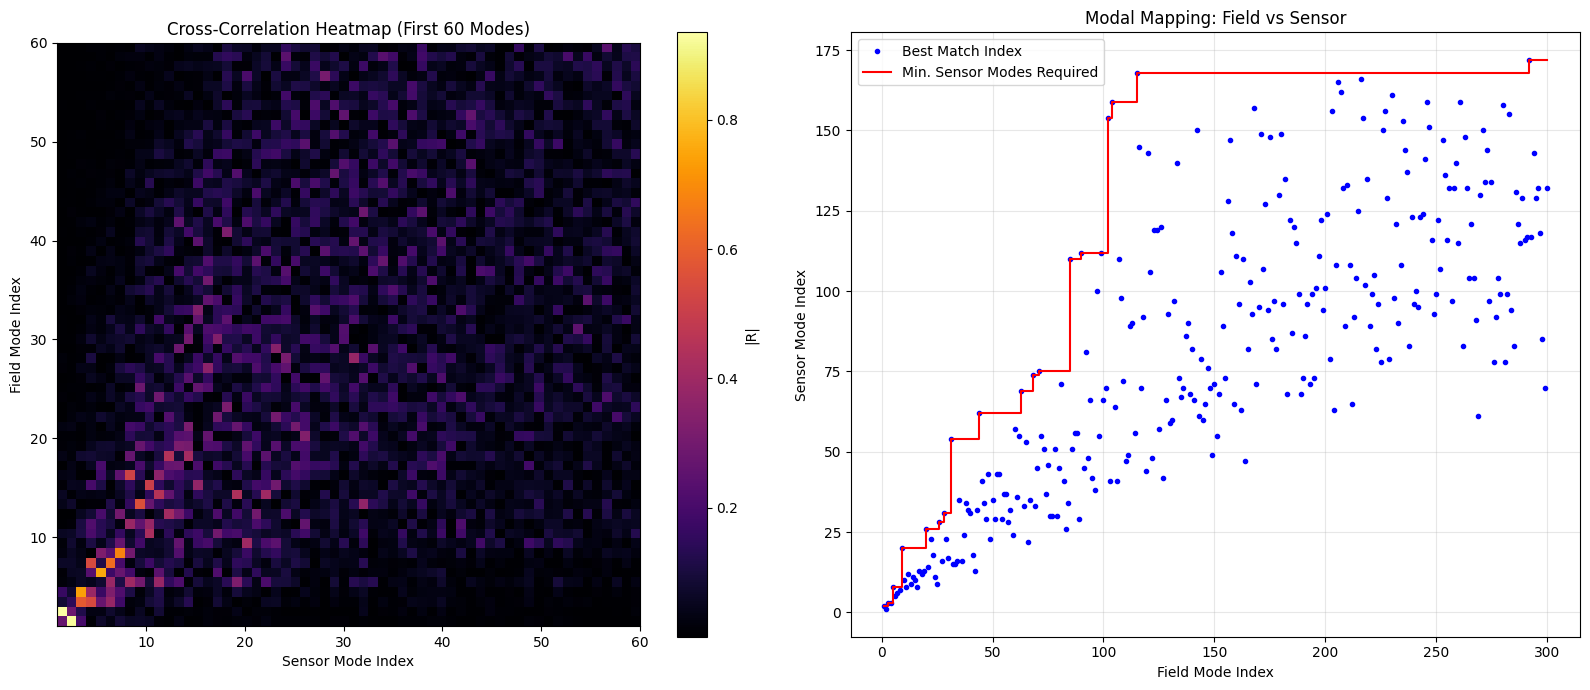


MODULATED PERIODIC POD ANALYSIS
10% Vel Error: Needs 25 Field Modes
   -> Requires at least 26 Sensor Modes
5% Vel Error: Needs 44 Field Modes
   -> Requires at least 62 Sensor Modes
1% Vel Error: Needs 123 Field Modes
   -> Requires at least 168 Sensor Modes
----------------------------------------
Top 5 Observability (Max Corr):
  Field Mode 1 matched to Sensor Mode 2 (R=0.9259)
  Field Mode 2 matched to Sensor Mode 1 (R=0.9355)
  Field Mode 3 matched to Sensor Mode 3 (R=0.5870)
  Field Mode 4 matched to Sensor Mode 3 (R=0.7408)
  Field Mode 5 matched to Sensor Mode 8 (R=0.3989)


In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# --- 1. CONFIGURATION ---
base_dir = "/media/chris-remote/Projects/ONeill/estimation"
output_dir = os.path.join(base_dir, "output/kevin_2cylinder/MP")
unified_h5 = os.path.join(output_dir, "MP_velocity_unified.h5")
os.makedirs(output_dir, exist_ok=True)

SENSOR_X = 10.0
TOLERANCE = 0.1
MAX_MODES = 300 

# --- 2. LOAD DATA ---
print("Loading unified velocity data...")
with h5py.File(unified_h5, 'r') as f:
    x = f['x'][:]
    y = f['y'][:]
    ux_train = f['train/ux'][:]
    uy_train = f['train/uy'][:]

# Extract Sensor Strip indices
sensor_mask = np.abs(x - SENSOR_X) < TOLERANCE
sensor_idx = np.where(sensor_mask)[0]
sensor_idx = sensor_idx[np.argsort(y[sensor_idx])]

print(f"Full Field: {ux_train.shape[1]} points | Sensor: {len(sensor_idx)} points")

# --- 3. COMPUTE PODs ---
print(f"Computing Full-Field POD...")
S_full = np.hstack([ux_train, uy_train])
pca_full = PCA(n_components=MAX_MODES, svd_solver='randomized', random_state=42)
a_full = pca_full.fit_transform(S_full - np.mean(S_full, axis=0))

print(f"Computing Sensor Strip POD...")
S_strip = np.hstack([ux_train[:, sensor_idx], uy_train[:, sensor_idx]])
pca_strip = PCA(n_components=MAX_MODES, svd_solver='randomized', random_state=42)
a_strip = pca_strip.fit_transform(S_strip - np.mean(S_strip, axis=0))

# --- 4. CROSS-CORRELATION ANALYSIS ---
print("Computing Cross-Correlation Matrix...")
# Standardize coefficients (Unit Variance) to compute correlation via dot product
a_f_norm = StandardScaler().fit_transform(a_full)
a_s_norm = StandardScaler().fit_transform(a_strip)

# R_ij: Correlation between Field Mode i and Sensor Mode j
R = (a_f_norm.T @ a_s_norm) / len(a_f_norm)
abs_R = np.abs(R)

# Max correlation for each field mode and which sensor mode provided it
max_corr_per_field_mode = np.max(abs_R, axis=1)
best_sensor_match = np.argmax(abs_R, axis=1) # 0-indexed

# Calculate "Required Sensor Modes"
# To capture field modes 1 to N, we need all sensor modes used in their best matches
req_sensor_modes = [np.max(best_sensor_match[:i+1]) + 1 for i in range(MAX_MODES)]

# Velocity-Scale L2 Error: sqrt(1 - cumulative_energy_ratio)
cum_energy_ratio = np.cumsum(pca_full.explained_variance_ratio_)
l2_error_vel = np.sqrt(np.maximum(1 - cum_energy_ratio, 0))

# --- 5. PLOTTING ---

# FIGURE 1: Convergence & Observability
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Global Field Mode Number')
ax1.set_ylabel('Velocity Scale L2 Error', color='tab:red')
ax1.plot(range(1, MAX_MODES+1), l2_error_vel, 'r-', linewidth=2, label='Relative L2 Error (Velocity Scale)')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(range(1, MAX_MODES+1), max_corr_per_field_mode, 'g.', alpha=0.6, label='Max Cross-Correlation')
ax2.set_ylabel('Max Correlation $|R_{max}|$', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.set_ylim(0, 1.1)

plt.title(f"Field Error vs. Sensor Observability (x={SENSOR_X})")
plt.savefig(os.path.join(output_dir, "convergence_observability.png"), dpi=200)

# FIGURE 2: Correlation Heatmap & Matching
fig, (ax_h, ax_m) = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap
im = ax_h.imshow(abs_R[:60, :60], origin='lower', cmap='inferno', extent=[1, 60, 1, 60])
ax_h.set_title("Cross-Correlation Heatmap (First 60 Modes)")
ax_h.set_xlabel("Sensor Mode Index")
ax_h.set_ylabel("Field Mode Index")
plt.colorbar(im, ax=ax_h, label="|R|")

# Matching Plot
ax_m.plot(range(1, MAX_MODES+1), best_sensor_match + 1, 'bo', markersize=3, label='Best Match Index')
ax_m.step(range(1, MAX_MODES+1), req_sensor_modes, 'r-', where='post', label='Min. Sensor Modes Required')
ax_m.set_title("Modal Mapping: Field vs Sensor")
ax_m.set_xlabel("Field Mode Index")
ax_m.set_ylabel("Sensor Mode Index")
ax_m.legend()
ax_m.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "correlation_mapping.png"), dpi=200)
plt.show()

# --- 6. SUMMARY REPORT ---
print("\n" + "="*40)
print("MODULATED PERIODIC POD ANALYSIS")
print("="*40)
target_errs = [0.1, 0.05, 0.01]
for te in target_errs:
    idx = np.where(l2_error_vel <= te)[0]
    if len(idx) > 0:
        n_f = idx[0] + 1
        n_s_req = req_sensor_modes[idx[0]]
        print(f"{te*100:g}% Vel Error: Needs {n_f} Field Modes")
        print(f"   -> Requires at least {n_s_req} Sensor Modes")

print("-" * 40)
print(f"Top 5 Observability (Max Corr):")
for i in range(5):
    print(f"  Field Mode {i+1} matched to Sensor Mode {best_sensor_match[i]+1} (R={max_corr_per_field_mode[i]:.4f})")
print("="*40)